**Author**: Felipe Matheus  
**Start Date**: 23/07/2026  
**End Date**: 24/07/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from autogluon.tabular import TabularPredictor

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper
from src.pipelines.AnnealingPipeline import AnnealingDataPipeline

from config.Variables import Variables
from config.bags_compositions import ALL_SAMPLES
from config.elements_coefficients import RESISTIVITY_FACTORS, ENRICHMENT_FACTORS

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()

## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
ANNEALING_SCHEMA_DATE = "020926"
SN_SCHEMA_DATE = "020926"

VARIABLE = "elongation"
PROCESS = f"annealing_{VARIABLE}"
TAG = f"model_{PROCESS}_{ANNEALING_SCHEMA_DATE}_LT-18"

# ---- Paths ----
FILE_NAME = f"dataset_{PROCESS}.csv"
FILE_NAME_SCHEMA_DATA = f"schema_annealing_essays_{ANNEALING_SCHEMA_DATE}.csv"
FILE_NAME_SN_COMPOSITION = f"serial-number-encoding_{SN_SCHEMA_DATE}.csv"
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"


# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "elongation_final"
FEATURES = ["initial_diameter", "GBEI", "tensile_strength", "purity", "elongation", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "best_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# # ---- Physical constraints (inference-time) ----
# Y_MAX = 105.0                     # physical ceiling for %IACS


In [4]:
ANNEALING_FEATURES = [
    "experiment_id",
    "material_reference",
    "purity",
    "initial_diameter",
    "temperature",
    "time",
    "iacs",
    "tensile_strength",
    "elongation",
    "iacs_final",
    "tensile_strength_final",
    "elongation_final",
]

In [5]:
pipe = AnnealingDataPipeline(
    df_annealing_schema_raw=pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA)),
    annealing_features=ANNEALING_FEATURES,
    df_sn=pd.read_csv(os.path.join(varv.PATHS.data_structured, FILE_NAME_SN_COMPOSITION)),
    all_samples=ALL_SAMPLES,    
    resistivity_factors=RESISTIVITY_FACTORS,
    enrichment_factors=ENRICHMENT_FACTORS
)


In [6]:
TEST_INPUT_SINGLE = {
    "initial_diameter": 1,
    "purity": 99.6985,
    # "IRI": 0.542737,
    # "iacs": 94.4,
    "temperature": 450+273,
    "time": 60.0,
    }


MATERIAL_PROPERTIES = {
    "initial_diameter": 1,
    "purity": 99.6985,
    # "IRI": 0.542737,
    # "iacs": 94.4,
    "tensile_strength": 367.73,
    "elongation": 6.39,
}


# 2. Data

In [7]:
pipe.df_iri_gbei

,experiment_id,material_reference,purity,initial_diameter,temperature,time,iacs,tensile_strength,elongation,iacs_final,tensile_strength_final,elongation_final,IRI,GBEI
0,ANE_SN010_CD1_RS1_WP1_202602171500-1,C14500,99.9000,1.900000,623,30.0,88.260,NaN,NaN,88.350000,NaN,NaN,1.300000,0.489800
1,ANE_SN010_CD1_RS1_WP1_202602171430-1,C14500,99.9000,1.900000,623,60.0,88.260,NaN,NaN,88.655000,NaN,NaN,1.300000,0.489800
2,ANE_SN010_CD1_RS1_WP1_202602171400-1,C14500,99.9000,1.900000,623,90.0,88.260,NaN,NaN,88.800000,NaN,NaN,1.300000,0.489800
3,ANE_SN011_CD1_RS1_WP1_202602181507-1,Cu-ETP,99.9000,2.160000,573,30.0,99.825,391.690000,4.90%,102.340000,249.78,48.60%,0.195105,0.001038
4,ANE_SN011_CD1_RS1_WP1_202603301900-1,Cu-ETP,99.9000,2.182333,573,30.0,99.390,387.595254,6.02%,102.230000,255.01,56.21%,0.195105,0.001038
5,ANE_SN011_CD1_RS1_WP1_202603311135-1,Cu-ETP,99.9000,2.182333,588,30.0,99.390,387.595254,6.02%,101.346667,NaN,NaN,0.195105,0.001038
6,ANE_SN011_CD1_RS1_WP1_202604031750-1,Cu-ETP,99.9000,2.191700,573,30.0,99.230,404.662322,3.53%,101.355000,NaN,NaN,0.195105,0.001038
7,ANE_SN011_CD1_RS1_WP1_202604031750-2,Cu-ETP,99.9000,2.196300,573,30.0,98.720,411.951845,3.27%,101.480000,NaN,NaN,0.195105,0.001038
8,ANE_CHIMIE_PARIS,Cu-T2,99.9000,1.200000,523,30.0,97.710,431.580000,0.94%,100.290000,247.08,20.15%,0.233275,0.002674
9,ANE_CHIMIE_PARIS,Cu-T2,99.9000,1.200000,523,60.0,97.710,431.580000,0.94%,100.420000,242.21,22.04%,0.233275,0.002674


In [8]:
pipe.df_sn

,ID,1A_sac1,1A_sac2,1B_sac1,1B_sac2,1B_sac3,1B_sac4,1B_sac5,1B_sac6,2N_sac1,2N_sac2,echantillon_2N,echantillon_1,echantillon_2,echantillon_3,echantillon_4
0,SN014,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.0000,0.0000,0.00000,0.000000,0.000,0.000
1,SN015,0.00000,0.00000,0.00000,0.40470,0.40470,0.00000,0.19060,0.00000,0.0000,0.0000,0.0000,0.00000,0.000000,0.000,0.000
2,SN016,0.00000,0.00000,0.00000,0.23050,0.23050,0.00000,0.23050,0.00000,0.2305,0.0780,0.0000,0.00000,0.000000,0.000,0.000
3,SN017,0.00000,0.00000,0.02050,0.21180,0.21180,0.00000,0.21180,0.00000,0.2118,0.1324,0.0000,0.00000,0.000000,0.000,0.000
4,SN019,0.30000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.6952,0.0048,0.00000,0.000000,0.000,0.000
5,SN020,0.20000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.7425,0.0575,0.00000,0.000000,0.000,0.000
6,SN021,0.02000,0.02000,0.00000,0.02000,0.02000,0.00000,0.02000,0.00000,0.0000,0.8798,0.0202,0.00000,0.000000,0.000,0.000
7,SN022,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.0000,1.0000,0.00000,0.000000,0.000,0.000
8,SN023,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.0000,1.0000,0.00000,0.000000,0.000,0.000
9,SN024,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.10000,0.0000,0.0000,0.0000,0.22500,0.225000,0.225,0.225


In [9]:
df, df_val = \
    pipe.get_elongation_df_df_val(features_elongation=FEATURES, target_elongation=TARGET)

In [10]:
df

,initial_diameter,GBEI,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,0.001038,391.690000,99.9000,4.90,573,30.0,48.60
1,2.182333,0.001038,387.595254,99.9000,6.02,573,30.0,56.21
2,1.200000,0.002674,431.580000,99.9000,0.94,523,30.0,20.15
3,1.200000,0.002674,431.580000,99.9000,0.94,523,60.0,22.04
4,1.200000,0.002674,431.580000,99.9000,0.94,523,90.0,24.62
5,1.200000,0.002674,431.580000,99.9000,0.94,573,30.0,24.72
6,1.200000,0.002674,431.580000,99.9000,0.94,573,60.0,27.43
7,1.200000,0.002674,431.580000,99.9000,0.94,573,90.0,25.24
8,1.200000,0.002674,431.580000,99.9000,0.94,623,30.0,27.06
9,1.200000,0.002674,431.580000,99.9000,0.94,623,60.0,26.17


In [11]:
df_val

,initial_diameter,GBEI,tensile_strength,purity,elongation,temperature,time,elongation_final
13,1.2,0.001038,397.09,99.9000,2.36,573,60.0,42.55
39,2.2,0.264027,362.31,99.7036,6.65,723,60.0,59.35
30,0.8,0.011525,347.70,99.9740,3.56,873,20.0,43.80
45,2.2,0.207493,367.04,99.7637,6.93,723,60.0,61.76
17,1.2,0.001038,397.09,99.9000,2.36,523,90.0,42.28
48,2.2,0.207493,367.04,99.7637,6.93,623,30.0,13.77
26,0.8,0.011525,347.70,99.9740,3.56,823,0.5,5.67
25,0.8,0.011525,347.70,99.9740,3.56,723,60.0,47.13
32,0.8,0.011525,347.70,99.9740,3.56,673,30.0,45.06
19,1.2,0.006830,335.21,99.9800,1.61,573,60.0,50.67


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [12]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.69 GB / 31.57 GB (18.0%)
Disk Space Avail:   700.19 GB / 932.08 GB (75.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\model_annealing_elongation_020926_LT-18\model_a"
Train Data Rows:    50
Train Data Columns: 7
Label Column:       elongation_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many un

In [13]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-8.337132,root_mean_squared_error,0.075137,3.629276,0.000000,0.011934,2,True,14
1,RandomForestMSE_BAG_L1,-9.096038,root_mean_squared_error,0.054989,0.634362,0.054989,0.634362,1,True,3
2,LightGBM_r131_BAG_L1,-9.938402,root_mean_squared_error,0.020148,2.982980,0.020148,2.982980,1,True,12
3,LightGBMLarge_BAG_L1,-10.388641,root_mean_squared_error,0.002004,1.799922,0.002004,1.799922,1,True,9
4,CatBoost_BAG_L1,-11.479688,root_mean_squared_error,0.005538,16.254952,0.005538,16.254952,1,True,4
5,CatBoost_r177_BAG_L1,-11.616922,root_mean_squared_error,0.007023,2.743328,0.007023,2.743328,1,True,10
6,ExtraTreesMSE_BAG_L1,-12.280037,root_mean_squared_error,0.043004,0.388262,0.043004,0.388262,1,True,5
7,XGBoost_BAG_L1,-12.578663,root_mean_squared_error,0.016906,1.577949,0.016906,1.577949,1,True,7
8,NeuralNetFastAI_r191_BAG_L1,-13.427768,root_mean_squared_error,0.054984,10.417789,0.054984,10.417789,1,True,13
9,NeuralNetTorch_r79_BAG_L1,-13.666719,root_mean_squared_error,0.039173,8.698843,0.039173,8.698843,1,True,11


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [14]:
# aml_h2o = modl.fit_h2o_automl(
#     df= df,
#     target= TARGET,
#     features= FEATURES,
#     weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
#     num_bag_folds= NUM_BAG_FOLDS_A,
#     use_shared_folds= USE_SHARED_FOLDS,
#     time_limit= TIME_LIMIT_A
# )

In [15]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [16]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(50,)  any NaN? False


## 4.1 fast check on big residuals

In [17]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual")], axis=1
)

df_verification.sort_values(by="residual")
# 

,initial_diameter,GBEI,tensile_strength,purity,elongation,temperature,time,elongation_final,elongation_final_pred,residual
26,0.800000,0.011525,347.700000,99.9740,3.56,823,0.5,5.67,44.799046,-39.129046
33,2.000000,0.040451,376.080000,99.9558,5.33,573,30.0,8.55,25.210464,-16.660464
40,2.200000,0.264027,362.310000,99.7036,6.65,623,30.0,10.74,23.660294,-12.920294
48,2.200000,0.207493,367.040000,99.7637,6.93,623,30.0,13.77,23.350586,-9.580586
28,0.800000,0.011525,347.700000,99.9740,3.56,573,60.0,6.39,14.938949,-8.548949
2,1.200000,0.002674,431.580000,99.9000,0.94,523,30.0,20.15,27.297112,-7.147112
3,1.200000,0.002674,431.580000,99.9000,0.94,523,60.0,22.04,28.399937,-6.359937
49,1.000000,0.268018,367.730000,99.6985,6.39,673,30.0,47.33,53.202042,-5.872042
7,1.200000,0.002674,431.580000,99.9000,0.94,573,90.0,25.24,30.689342,-5.449342
27,0.800000,0.011525,347.700000,99.9740,3.56,573,30.0,5.84,11.098191,-5.258191


## 4.2 Recovering weights 

In [18]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (13, 50)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1', 'NeuralNetTorch_r79_BAG_L1', 'LightGBM_r131_BAG_L1', 'NeuralNetFastAI_r191_BAG_L1']


In [19]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000002  (OK)

Non-zero weights:
  RandomForestMSE_BAG_L1          0.6000
  LightGBM_r131_BAG_L1            0.4000


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [20]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    5.000000e+01
mean     7.974720e-07
std      5.204097e-07
min      2.858044e-09
25%      4.489393e-07
50%      7.406045e-07
75%      1.363830e-06
max      1.572338e-06
Name: elongation_final, dtype: float64

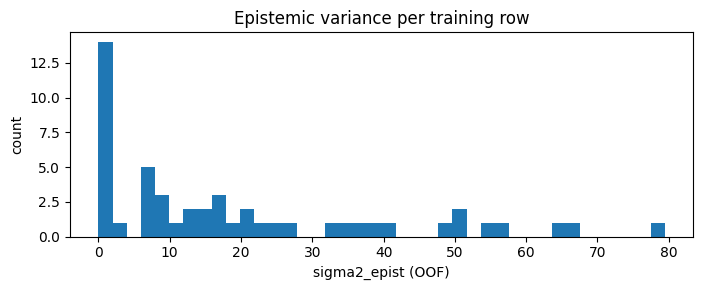

In [21]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [22]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    50.000000
mean      3.975910
std       4.591427
min       0.099800
25%       1.305936
50%       2.005997
75%       5.966071
max      20.445522
Name: elongation_final, dtype: float64

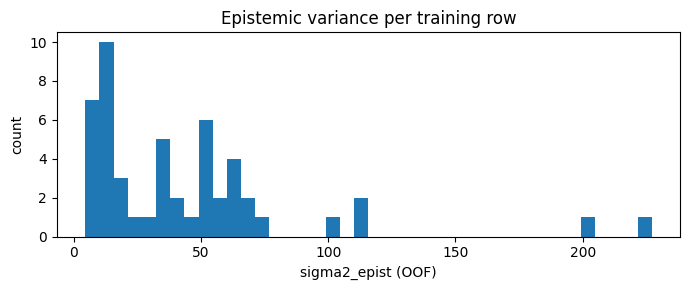

In [23]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [24]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 50
  n_truncated          = 20
  pct_truncated        = 40.0
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 1530.5845513239133
  r_tilde_sq_mean      = 57.024736066475164
  r_tilde_sq_median    = 5.300665293524149


In [25]:
r_tilde_sq

array([4.76335593e+01, 1.66259275e+02, 2.77597135e+01, 0.00000000e+00,
       0.00000000e+00, 3.86344378e+00, 0.00000000e+00, 3.61655821e+00,
       0.00000000e+00, 0.00000000e+00, 1.91300699e+00, 0.00000000e+00,
       4.24933719e+01, 0.00000000e+00, 5.06515219e+00, 0.00000000e+00,
       3.38337042e+01, 0.00000000e+00, 0.00000000e+00, 3.73711152e+01,
       0.00000000e+00, 4.98486157e+01, 0.00000000e+00, 1.42563686e+01,
       2.47273822e+01, 1.13730032e+01, 1.53058455e+03, 0.00000000e+00,
       2.29033631e+01, 1.02760997e+01, 0.00000000e+00, 5.66076138e+01,
       5.53617840e+00, 2.71342730e+02, 5.40466176e+01, 0.00000000e+00,
       0.00000000e+00, 6.83991155e+00, 0.00000000e+00, 0.00000000e+00,
       1.18096287e+02, 0.00000000e+00, 1.68088188e+01, 6.32961182e-01,
       8.44791674e+01, 1.05005439e+01, 9.08285411e+01, 3.48775850e+01,
       6.68615638e+01, 0.00000000e+00])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [26]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.95 GB / 31.57 GB (15.7%)
Disk Space Avail:   700.16 GB / 932.08 GB (75.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\model_annealing_elongation_020926_LT-18\model_b"
Train Data Rows:    50
Train Data Columns: 7
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many uniqu

In [27]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-8.049637,root_mean_squared_error,0.052678,9.245367,0.000000,0.014647,2,True,10
1,NeuralNetFastAI_BAG_L1,-8.049637,root_mean_squared_error,0.052678,9.230721,0.052678,9.230721,1,True,6
2,LightGBMLarge_BAG_L1,-8.313624,root_mean_squared_error,0.005038,3.693332,0.005038,3.693332,1,True,9
3,LightGBM_BAG_L1,-8.389111,root_mean_squared_error,0.009591,2.000816,0.009591,2.000816,1,True,2
4,LightGBMXT_BAG_L1,-8.391731,root_mean_squared_error,0.002318,2.017105,0.002318,2.017105,1,True,1
5,CatBoost_BAG_L1,-8.397808,root_mean_squared_error,0.006036,2.468833,0.006036,2.468833,1,True,4
6,NeuralNetTorch_BAG_L1,-8.431472,root_mean_squared_error,0.041675,12.351729,0.041675,12.351729,1,True,8
7,XGBoost_BAG_L1,-8.620002,root_mean_squared_error,0.014359,1.433511,0.014359,1.433511,1,True,7
8,ExtraTreesMSE_BAG_L1,-10.556136,root_mean_squared_error,0.058296,0.573595,0.058296,0.573595,1,True,5
9,RandomForestMSE_BAG_L1,-10.756003,root_mean_squared_error,0.067454,0.584639,0.067454,0.584639,1,True,3


In [28]:
predictor_b.predict_oof()  

0    -2.373794
1    -0.364446
2    -3.436442
3    -3.785288
4    -7.165811
5    -7.788856
6    -6.076763
7    -5.039023
8    -7.218465
9    -5.821332
10   -6.456697
11   -6.629029
12   -6.875528
13   -2.135908
14   -5.716174
15   -7.592960
16   -6.393197
17   -6.129964
18   -5.280579
19   -4.305645
20   -3.611596
21   -5.844603
22   -4.234408
23   -4.527150
24   -1.327472
25   -4.123172
26   -4.540676
27   -3.298172
28   -4.545807
29   -3.152205
30   -1.428184
31   -2.773009
32   -3.305102
33   -1.457115
34   -1.444687
35   -2.838392
36   -6.085008
37   -0.979515
38   -3.069031
39   -5.539835
40   -3.215401
41   -2.801297
42   -7.265546
43   -0.839357
44   -1.469539
45   -2.572949
46   -1.931090
47   -1.944977
48   -3.312423
49   -6.441638
Name: log_r_tilde_sq, dtype: float32

In [29]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    f"{TARGET}": df[f"{TARGET}"],
    f"{TARGET}_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,elongation_final,elongation_final_final
0,6.901834,-2.373794,0.001755,48.60,48.60
1,13.690156,-0.364446,21.161095,56.21,56.21
2,-7.147112,-3.436442,23.321489,20.15,20.15
3,-6.359937,-3.785288,50.270438,22.04,22.04
4,-2.508660,-7.165811,35.723584,24.62,24.62
5,-3.318338,-7.788856,7.147921,24.72,24.72
6,-2.009886,-6.076763,37.539093,27.43,27.43
7,-5.449342,-5.039023,26.078775,25.24,25.24
8,-0.589490,-7.218465,8.946388,27.06,27.06
9,-4.131205,-5.821332,17.120354,26.17,26.17


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [30]:
df[TARGET].var()

np.float64(318.5355616734694)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [31]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.34,-0.16
1,0.80,0.58,-0.22
2,0.90,0.64,-0.26
3,0.95,0.78,-0.17


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [32]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.9324

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.60,0.10
1,0.80,0.86,0.06
2,0.90,0.92,0.02
3,0.95,0.92,-0.03


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [33]:
c_opt
weights

array([0.00000000e+00, 7.43255031e-09, 5.99999993e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.99999998e-01,
       2.04597683e-09])

In [46]:
len(base_model_names)
len(weights)

13

In [35]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df.copy(), # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
)

val_metrics = evla.metrics_on_dataframe(
    df=df.copy(), #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 5.0746, 'mae': 3.5883, 'mape': 22.2977, 'r2': 0.9175}
coverage: {0.5: 0.8, 0.8: 0.88, 0.9: 0.94, 0.95: 1.0}


In [36]:
# # ---- Target-agnostic point prediction from a plain dict ----
# single = modl.predict_target(
#     predictor_a,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
# )
# print(f"Predicted {TARGET}: {single[0]:.3f}")

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [37]:
df.head(5)

,initial_diameter,GBEI,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,0.001038,391.690000,99.9,4.90,573,30.0,48.60
1,2.182333,0.001038,387.595254,99.9,6.02,573,30.0,56.21
2,1.200000,0.002674,431.580000,99.9,0.94,523,30.0,20.15
3,1.200000,0.002674,431.580000,99.9,0.94,523,60.0,22.04
4,1.200000,0.002674,431.580000,99.9,0.94,523,90.0,24.62


In [38]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier
0,46.430817,0.118908,3.185356,12.338406,3.512607,46.430817,1.000000
1,49.382870,1.408470,3.185356,17.153743,4.141708,49.382870,1.016161
2,26.106241,35.685594,3.185356,145.147503,12.047718,26.106241,1.000000
3,27.867051,47.434794,3.185356,189.020040,13.748456,27.867052,1.000000
4,28.842311,37.100232,3.185356,150.429885,12.264986,28.842312,1.000000


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [39]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_elongation\model_annealing_elongation_020926_LT-18\artifacts.pkl


In [40]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": ANNEALING_SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_elongation\model_annealing_elongation_020926_LT-18\global_config.txt


In [41]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
# h2o_oof_preds = (
#     aml_h2o.leader.cross_validation_holdout_predictions()
#     .as_data_frame()
#     .iloc[:, 0]
#     .to_numpy()
# )

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
# metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        # {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
# leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
# leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae       mape        r2
0  AutoGluon (Model A, leader)  8.337132  5.715444  34.867261  0.777336
Saved to: ../../models/annealing_elongation\model_annealing_elongation_020926_LT-18


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [42]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'ood_ref']
Target: elongation_final
Features: ['initial_diameter', 'GBEI', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']


In [43]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    # y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier
0,46.430817,0.118908,3.185356,12.338406,3.512607,46.430817,1.000000
1,49.382870,1.408470,3.185356,17.153743,4.141708,49.382870,1.016161
2,26.106241,35.685594,3.185356,145.147503,12.047718,26.106241,1.000000
3,27.867051,47.434794,3.185356,189.020040,13.748456,27.867052,1.000000
4,28.842311,37.100232,3.185356,150.429885,12.264986,28.842312,1.000000


In [44]:
# # ---- 4) Target-agnostic quick prediction from a plain dict ----
# # Works for any predictor/target via modl.predict_target (features inferred
# # from the predictor when not passed explicitly).
# single_loaded = modl.predict_target(
#     predictor_a_loaded,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
#     features=loaded_artifacts["features"],
# )
# print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [45]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
